# Notebook 3: TsSHAP vs TSICE Comparison

This notebook compares TsSHAP feature importances with TSICE (Time Series ICE) values.

TSICE computes Individual Conditional Expectation curves by perturbing each
lag position and measuring the forecast change.  TsSHAP uses SHAP values on a
surrogate model trained on interpretable features.

We compare them on:
1. **Rank correlation** of lag feature importances on synthetic data
2. **Visual side-by-side** bar charts
3. **Correctness sanity check** — does the top-ranked lag match the forecaster's logic?

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from evaluation.synthetic_data import make_trend_seasonal
from evaluation.tsice_comparison import run_tsice, compare_rankings, plot_comparison
from tsshap import TsSHAPExplainer
from tsshap.features import LagFeatures, SeasonalLagFeatures, STLFeatures, TrendFeatures
from tsshap.forecasters import MovingAverageForecaster, SeasonalNaiveForecaster, NaiveForecaster

## Setup: synthetic series with dominant lag-1 structure (Naive forecaster)
For a Naive forecaster, `y(t-1)` should dominate.  Both TsSHAP and TSICE should agree.

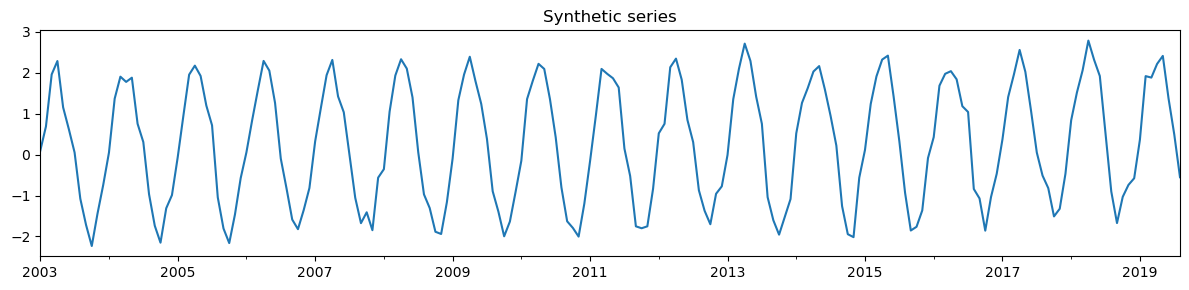

In [2]:
synth = make_trend_seasonal(
    n=200, period=12,
    trend_slope=0.5,
    seasonal_amplitude=2.0,
    noise_std=0.3,
    freq='ME',
    seed=42,
)
y = synth.series

y.plot(title='Synthetic series', figsize=(12, 3))
plt.tight_layout()
plt.show()

## TsSHAP importances (lag features only, for fair comparison with TSICE)

In [3]:
forecaster = NaiveForecaster()

explainer = TsSHAPExplainer(
    forecaster=forecaster,
    feature_extractors=[
        LagFeatures(lags=12),
        SeasonalLagFeatures(lags=1, period=12),
        STLFeatures(period=12),
        TrendFeatures(degree=1),
    ],
    horizon=6,
)
explainer.fit(y)

result = explainer.explain(scope='global')
print('Top TsSHAP features:')
print(result.top_features(8))

Top TsSHAP features:
y(t-1)    1.276618
y(t-7)    0.023628
t1        0.010530
y(t-4)    0.007019
y(t-6)    0.006213
y(t-8)    0.005389
y(t-2)    0.005070
y(t-3)    0.004137
dtype: float32


## TSICE importances

In [4]:
tsice_imp = run_tsice(
    y=y,
    forecaster=NaiveForecaster(),
    horizon=1,
    n_samples=15,
)

# Show top-12 lag importances
tsice_series = pd.Series(tsice_imp).sort_values(ascending=False)
print('Top TSICE lag importances:')
print(tsice_series.head(12))

Top TSICE lag importances:
y(t-1)      1.024971
y(t-138)    0.000000
y(t-128)    0.000000
y(t-129)    0.000000
y(t-130)    0.000000
y(t-131)    0.000000
y(t-132)    0.000000
y(t-133)    0.000000
y(t-134)    0.000000
y(t-135)    0.000000
y(t-136)    0.000000
y(t-137)    0.000000
dtype: float64


## Rank correlation comparison

In [5]:
comparison = compare_rankings(result.feature_importance, tsice_imp)
print(f"Spearman ρ (TsSHAP vs TSICE):  {comparison['spearman_rho']:.4f}")
print(f"p-value:                        {comparison['p_value']:.4f}")
print(f"Common lag features:            {comparison['n_common_features']}")

Spearman ρ (TsSHAP vs TSICE):  0.4804
p-value:                        0.1139
Common lag features:            12


## Side-by-side importance plot

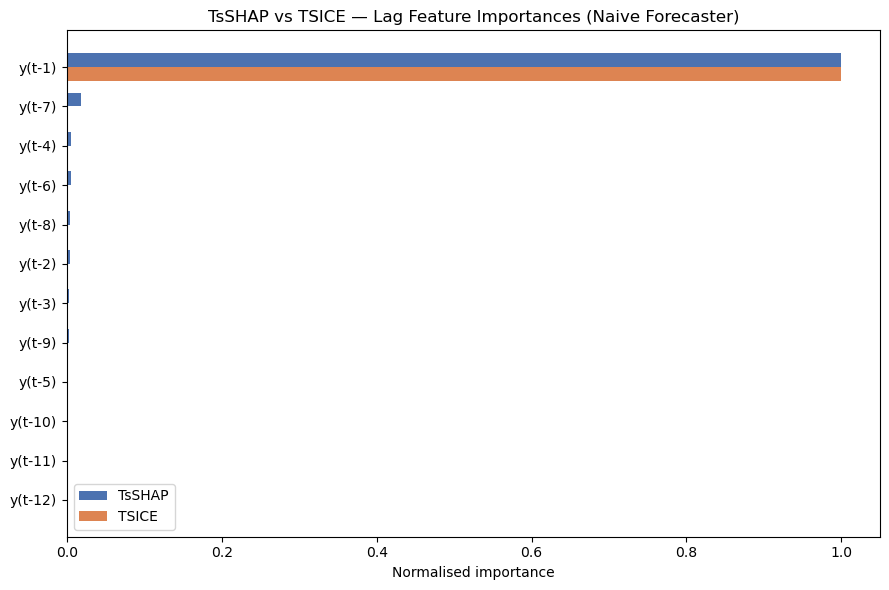

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_comparison(
    result.feature_importance,
    tsice_imp,
    top_n=12,
    ax=ax,
    title='TsSHAP vs TSICE — Lag Feature Importances (Naive Forecaster)',
)
plt.show()

## Comparison across forecasters

In [7]:
results_table = []

for fc_name, fc in [
    ('Naive', NaiveForecaster()),
    ('SeasonalNaive', SeasonalNaiveForecaster(period=12)),
    ('MovingAverage', MovingAverageForecaster(k=6)),
]:
    exp = TsSHAPExplainer(
        forecaster=fc,
        feature_extractors=[LagFeatures(lags=12), SeasonalLagFeatures(lags=1, period=12)],
        horizon=6,
    )
    exp.fit(y)
    r = exp.explain(scope='global')

    tsice = run_tsice(y=y, forecaster=fc, horizon=1, n_samples=10)
    comp = compare_rankings(r.feature_importance, tsice)

    results_table.append({
        'forecaster': fc_name,
        'top_tsshap': r.top_features(1).index[0],
        'top_tsice':  max(tsice, key=tsice.get),
        'spearman_rho': round(comp['spearman_rho'], 3),
    })

pd.DataFrame(results_table)

,forecaster,top_tsshap,top_tsice,spearman_rho
0,Naive,y(t-1),y(t-1),0.480
1,SeasonalNaive,y(t-12),y(t-12),0.480
2,MovingAverage,y(t-3),y(t-5),0.571


## Interpretation

A high Spearman ρ indicates that TsSHAP and TSICE agree on which lag features drive the forecast.

- For the **Naive** forecaster, both methods should rank `y(t-1)` first.
- For **SeasonalNaive(m=12)**, both should rank `y(t-12)` first.
- For **MovingAverage(k=6)**, both should give roughly equal importance to `y(t-1)` through `y(t-6)`.

This provides a correctness sanity check: if TsSHAP produces importances consistent with TSICE
on interpretable baseline forecasters, it gives us confidence in its outputs for black-box models.